# 01 EDA Main Table

EDA for the main Home Credit application tables:

- `application_train.csv`
- `application_test.csv`


In [16]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
TRAIN_PATH = RAW_DIR / "application_train.csv"
TEST_PATH = RAW_DIR / "application_test.csv"

TRAIN_PATH, TEST_PATH

(PosixPath('/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/data/raw/application_train.csv'),
 PosixPath('/mnt/c/Users/arand/OneDrive/Desktop/NEU/ds4400/final_project/data/raw/application_test.csv'))

In [2]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (307511, 122)
Test shape: (48744, 121)


In [3]:
schema_summary = pd.DataFrame([
    {
        "table": "application_train",
        "rows": train_df.shape[0],
        "cols": train_df.shape[1],
        "numeric_cols": int((train_df.dtypes != "object").sum()),
        "categorical_cols": int((train_df.dtypes == "object").sum()),
    },
    {
        "table": "application_test",
        "rows": test_df.shape[0],
        "cols": test_df.shape[1],
        "numeric_cols": int((test_df.dtypes != "object").sum()),
        "categorical_cols": int((test_df.dtypes == "object").sum()),
    },
])
display(schema_summary)

common_cols = sorted(set(train_df.columns).intersection(test_df.columns))
train_only_cols = sorted(set(train_df.columns) - set(test_df.columns))
test_only_cols = sorted(set(test_df.columns) - set(train_df.columns))

print("Common columns:", len(common_cols))
print("Train-only columns:", train_only_cols)
print("Test-only columns:", test_only_cols)

,table,rows,cols,numeric_cols,categorical_cols
0,application_train,307511,122,122,0
1,application_test,48744,121,121,0


Common columns: 121
Train-only columns: ['TARGET']
Test-only columns: []


In [4]:
print("Train dtype counts:")
print(train_df.dtypes.value_counts())

print("\nFirst 5 rows of train:")
display(train_df.head())

Train dtype counts:
float64    65
int64      41
str        16
Name: count, dtype: int64

First 5 rows of train:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
target_counts = train_df["TARGET"].value_counts().sort_index()
target_props = train_df["TARGET"].value_counts(normalize=True).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_props,
})
display(target_summary)
print("Default rate:", round(train_df["TARGET"].mean(), 4))

,count,proportion
TARGET,,
0,282686,0.919271
1,24825,0.080729


Default rate: 0.0807


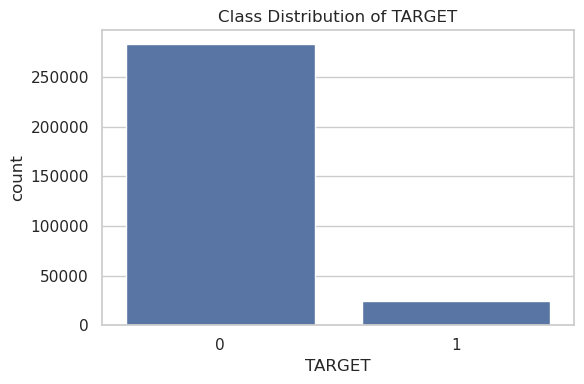

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="TARGET")
plt.title("Class Distribution of TARGET")
plt.tight_layout()
plt.show()

In [7]:
train_missing = train_df.isna().mean().sort_values(ascending=False)
test_missing = test_df.isna().mean().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "train_missing_pct": train_missing * 100,
    "test_missing_pct": test_missing.reindex(train_missing.index, fill_value=0) * 100,
}).sort_values("train_missing_pct", ascending=False)

display(missing_summary.head(20))

,train_missing_pct,test_missing_pct
COMMONAREA_AVG,69.872297,68.716150
COMMONAREA_MODE,69.872297,68.716150
COMMONAREA_MEDI,69.872297,68.716150
NONLIVINGAPARTMENTS_MEDI,69.432963,68.412523
NONLIVINGAPARTMENTS_MODE,69.432963,68.412523
NONLIVINGAPARTMENTS_AVG,69.432963,68.412523
FONDKAPREMONT_MODE,68.386172,67.284179
LIVINGAPARTMENTS_AVG,68.354953,67.249302
LIVINGAPARTMENTS_MEDI,68.354953,67.249302
LIVINGAPARTMENTS_MODE,68.354953,67.249302


<Figure size 1000x700 with 0 Axes>

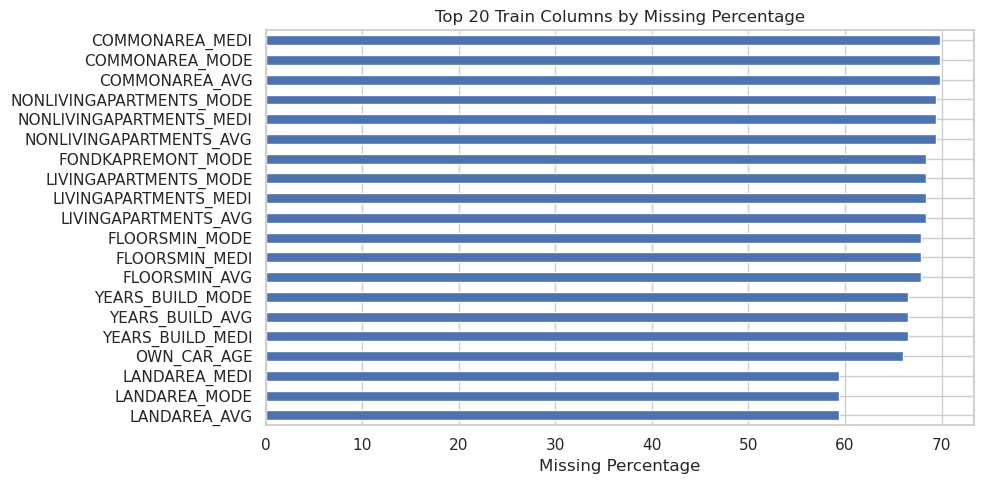

In [8]:
plt.figure(figsize=(10, 7))
missing_summary.head(20).sort_values("train_missing_pct").plot(
    kind="barh",
    y="train_missing_pct",
    legend=False,
)
plt.title("Top 20 Train Columns by Missing Percentage")
plt.xlabel("Missing Percentage")
plt.tight_layout()
plt.show()

In [9]:
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Number of numeric columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))

categorical_cardinality = pd.DataFrame({
    "feature": categorical_cols,
    "n_unique": [train_df[col].nunique(dropna=True) for col in categorical_cols],
}).sort_values("n_unique", ascending=False)

display(categorical_cardinality)

Number of numeric columns: 106
Number of categorical columns: 16


,feature,n_unique
11,ORGANIZATION_TYPE,58
9,OCCUPATION_TYPE,18
5,NAME_INCOME_TYPE,8
4,NAME_TYPE_SUITE,7
14,WALLSMATERIAL_MODE,7
10,WEEKDAY_APPR_PROCESS_START,7
7,NAME_FAMILY_STATUS,6
8,NAME_HOUSING_TYPE,6
6,NAME_EDUCATION_TYPE,5
12,FONDKAPREMONT_MODE,4


In [10]:
print(train_df[numeric_cols].describe().T.head(20))

                               count           mean            std  \
SK_ID_CURR                  307511.0  278180.518577  102790.175348   
TARGET                      307511.0       0.080729       0.272419   
CNT_CHILDREN                307511.0       0.417052       0.722121   
AMT_INCOME_TOTAL            307511.0  168797.919297  237123.146279   
AMT_CREDIT                  307511.0  599025.999706  402490.776996   
AMT_ANNUITY                 307499.0   27108.573909   14493.737315   
AMT_GOODS_PRICE             307233.0  538396.207429  369446.460540   
REGION_POPULATION_RELATIVE  307511.0       0.020868       0.013831   
DAYS_BIRTH                  307511.0  -16036.995067    4363.988632   
DAYS_EMPLOYED               307511.0   63815.045904  141275.766519   
DAYS_REGISTRATION           307511.0   -4986.120328    3522.886321   
DAYS_ID_PUBLISH             307511.0   -2994.202373    1509.450419   
OWN_CAR_AGE                 104582.0      12.061091      11.944812   
FLAG_MOBIL          

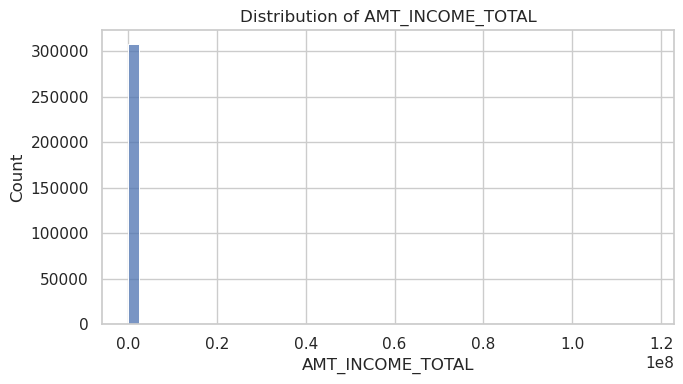

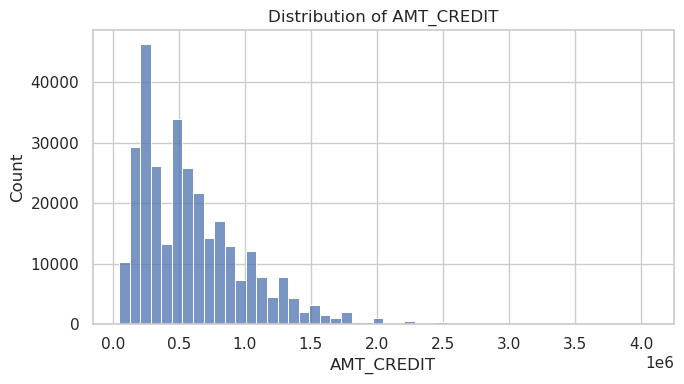

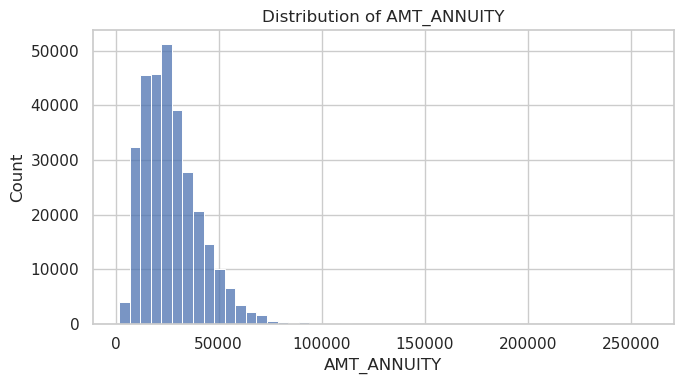

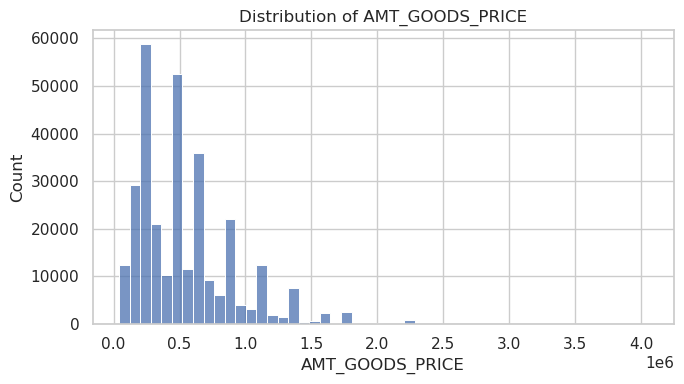

In [11]:
features_to_plot = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
]

for col in features_to_plot:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_8032/3778852273.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["YEARS_BIRTH"] = (-train_df["DAYS_BIRTH"]) / 365
/tmp/ipykernel_8032/3778852273.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["YEARS_EMPLOYED"] = train_df["DAYS_EMPLOYED"].replace(365243, np.nan)


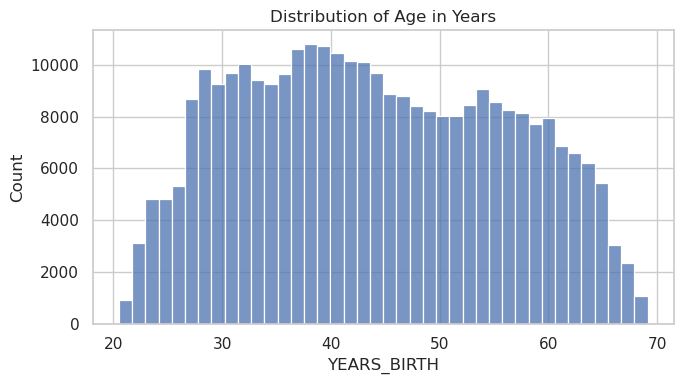

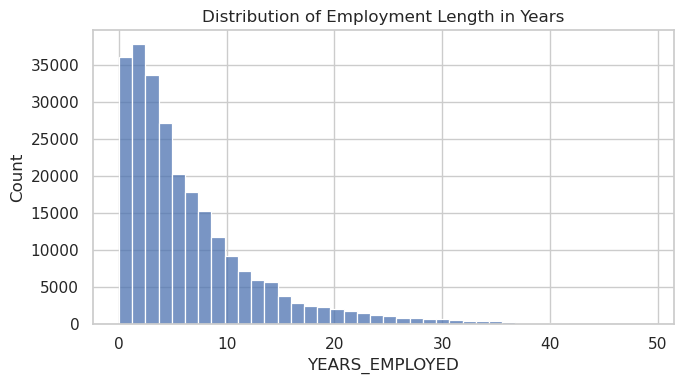

In [12]:
train_df["YEARS_BIRTH"] = (-train_df["DAYS_BIRTH"]) / 365
train_df["YEARS_EMPLOYED"] = train_df["DAYS_EMPLOYED"].replace(365243, np.nan)
train_df["YEARS_EMPLOYED"] = (-train_df["YEARS_EMPLOYED"]) / 365

for col, title in [
    ("YEARS_BIRTH", "Distribution of Age in Years"),
    ("YEARS_EMPLOYED", "Distribution of Employment Length in Years"),
]:
    plt.figure(figsize=(7, 4))
    sns.histplot(train_df[col].dropna(), bins=40)
    plt.title(title)
    plt.tight_layout()
    plt.show()

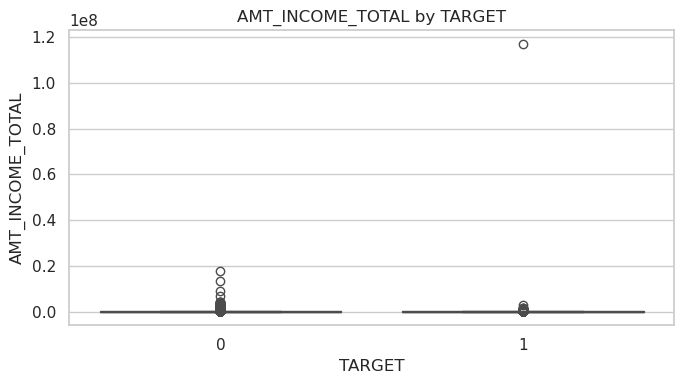

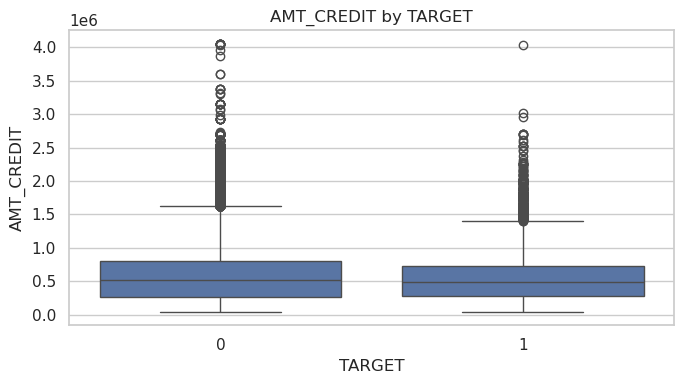

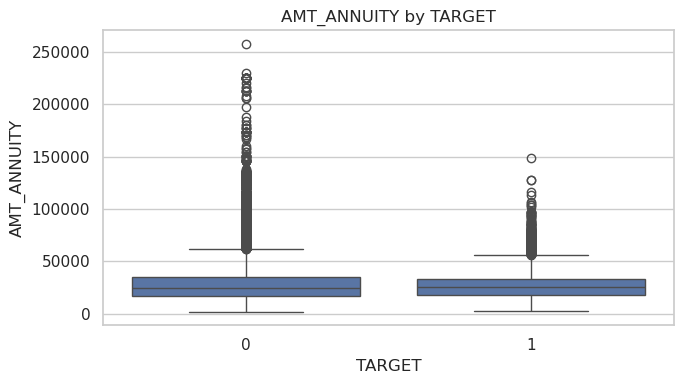

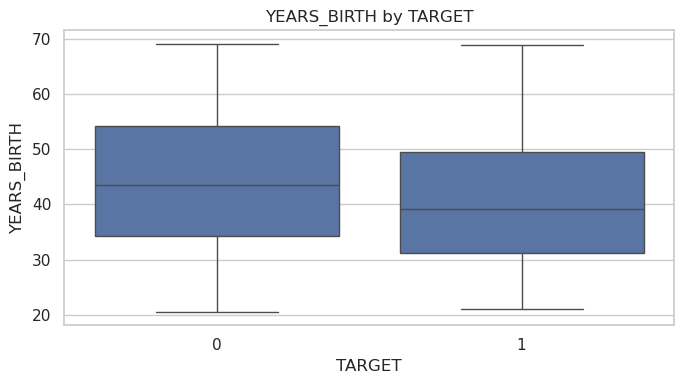

In [13]:
boxplot_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "YEARS_BIRTH",
]

for col in boxplot_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=train_df, x="TARGET", y=col)
    plt.title(f"{col} by TARGET")
    plt.tight_layout()
    plt.show()

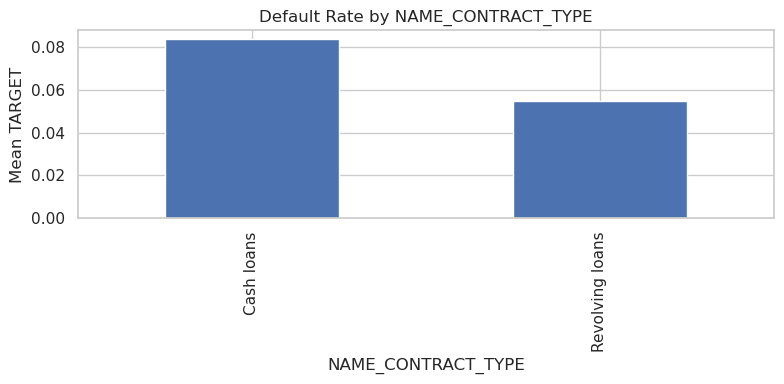

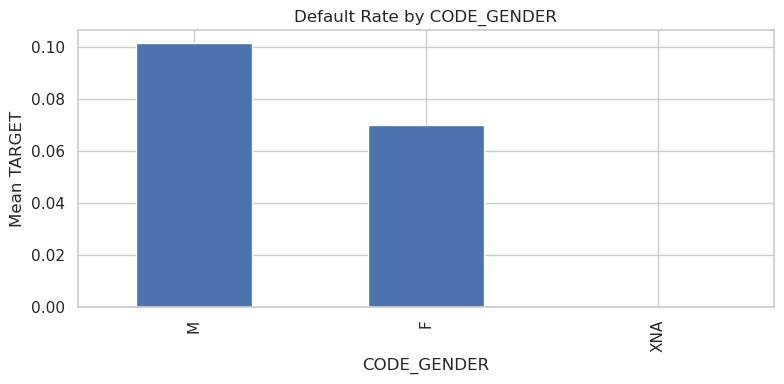

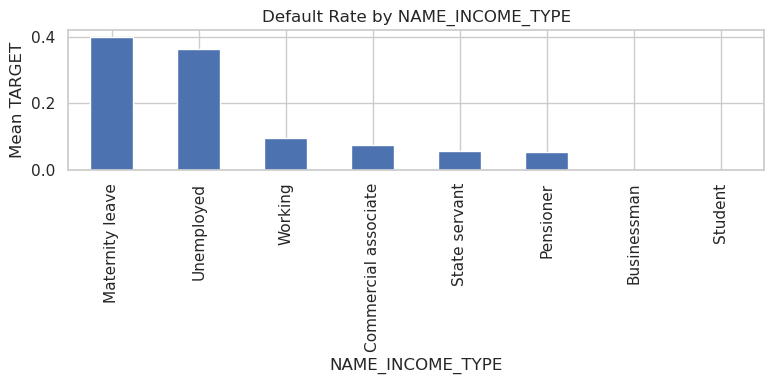

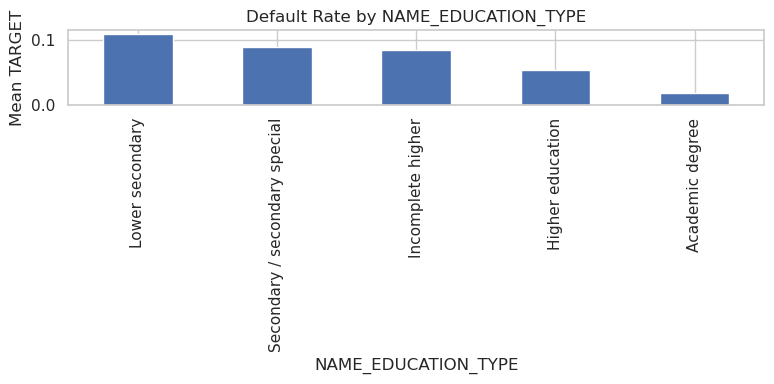

In [14]:
cat_features_to_plot = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
]

for col in cat_features_to_plot:
    default_rate = train_df.groupby(col)["TARGET"].mean().sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    default_rate.plot(kind="bar")
    plt.title(f"Default Rate by {col}")
    plt.ylabel("Mean TARGET")
    plt.tight_layout()
    plt.show()

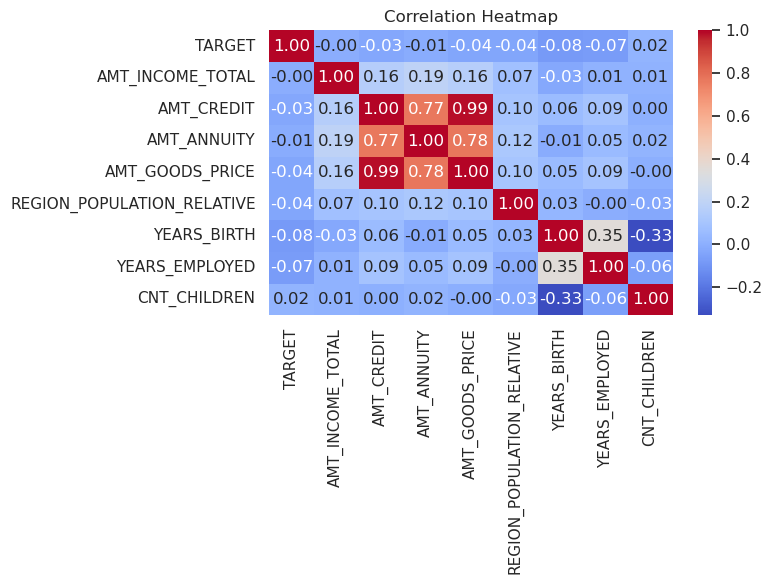

In [15]:
selected_corr_cols = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "REGION_POPULATION_RELATIVE",
    "YEARS_BIRTH",
    "YEARS_EMPLOYED",
    "CNT_CHILDREN",
]

corr = train_df[selected_corr_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()